# 70/30 Illumination + Augmentation — Expanded Dataset Training
**Attack:** `illumination` (default). **Split:** 70% of training images get the attack, 30% stay clean  
**Expansion:** Every image (clean or attacked) is saved a second time with random Albumentations augmentation → ~2x effective dataset size  
**Model:** Fine-tuned from `best.pt` (baseline) for 50 epochs  

### Augmentation pipeline applied to ALL images:
- Horizontal flip
- Random brightness / contrast jitter
- Hue-saturation-value shift
- Gaussian blur
- CLAHE (contrast enhancement)
- Image compression noise
- Random shadow overlay

---
### ⚙️ Configuration — change these before running
This notebook defaults to `'illumination'` in **Step 2**. You can change `ATTACK_TYPE` to `'tape'`, `'patch'`, or `'graffiti'` if needed.

---
### Setup Instructions
1. Place `archive.zip` in the project root and baseline weights at `models/best.pt`
2. (Optional) Use a GPU runtime if available
3. Run all cells in order

In [1]:
!pip install ultralytics albumentations matplotlib --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os

# Optional Colab-only drive mount
if os.path.exists('/content'):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass

In [3]:
import torch
print(f"Is GPU available? {torch.cuda.is_available()}")
# This should print: Is GPU available? True
# If False, change runtime type to T4 GPU, then restart session

Is GPU available? True


In [4]:
import zipfile
import os
from pathlib import Path

IS_COLAB = os.path.exists('/content') and os.access('/content', os.W_OK)

if IS_COLAB:
    ROOT_DIR = '/content'
else:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    root_candidate = next((p for p in candidates if (p / 'archive.zip').exists()), None)
    ROOT_DIR = str(root_candidate if root_candidate else cwd)

DATASETS_DIR = os.path.join(ROOT_DIR, 'datasets')
ARCHIVE_ZIP = os.path.join(ROOT_DIR, 'archive.zip')
ARCHIVE_DIR = os.path.join(DATASETS_DIR, 'archive')

if not os.path.exists(ARCHIVE_ZIP):
    raise FileNotFoundError(f"archive.zip not found at: {ARCHIVE_ZIP}")

os.makedirs(DATASETS_DIR, exist_ok=True)
with zipfile.ZipFile(ARCHIVE_ZIP, 'r') as zip_ref:
    zip_ref.extractall(ARCHIVE_DIR)

print('Dataset extracted.')
print(f'ROOT_DIR: {ROOT_DIR}')
print(f'ARCHIVE_DIR: {ARCHIVE_DIR}')

Dataset extracted.
ROOT_DIR: C:\Users\Karim\Desktop\Road-Sign-Detection-Model
ARCHIVE_DIR: C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive


## Step 1 — All Attack Functions

In [5]:
import random
import shutil
import cv2
import os
import numpy as np
import albumentations as A


def apply_digital_tape(image, bbox, color=(50, 50, 50), thickness_ratio=0.2):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1 = int((x_center - b_w / 2) * w)
    x2 = int((x_center + b_w / 2) * w)
    y1 = int((y_center - b_h / 2) * h)
    y2 = int((y_center + b_h / 2) * h)
    tape_h  = int((y2 - y1) * thickness_ratio)
    tape_y1 = int(y_center * h - tape_h / 2)
    tape_y2 = int(y_center * h + tape_h / 2)
    cv2.rectangle(image, (x1, tape_y1), (x2, tape_y2), color, -1)
    return image


def apply_adversarial_patch(image, bbox):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1 = int((x_center - b_w / 4) * w)
    y1 = int((y_center - b_h / 4) * h)
    x2 = int((x_center + b_w / 4) * w)
    y2 = int((y_center + b_h / 4) * h)
    patch_h = max(1, y2 - y1)
    patch_w = max(1, x2 - x1)
    image[y1:y2, x1:x2] = np.random.randint(0, 255, (patch_h, patch_w, 3), dtype=np.uint8)
    return image


def apply_graffiti(image, bbox, num_elements=6):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1 = int((x_center - b_w / 2) * w)
    y1 = int((y_center - b_h / 2) * h)
    x2 = int((x_center + b_w / 2) * w)
    y2 = int((y_center + b_h / 2) * h)
    sign_w = max(1, x2 - x1)
    sign_h = max(1, y2 - y1)

    def rand_point():
        return (int(np.random.uniform(x1, x2)), int(np.random.uniform(y1, y2)))

    def rand_color():
        hue = np.random.randint(0, 180)
        bgr = cv2.cvtColor(np.array([[[hue, 220, 200]]], dtype=np.uint8), cv2.COLOR_HSV2BGR)[0][0]
        return (int(bgr[0]), int(bgr[1]), int(bgr[2]))

    overlay = image.copy()
    for _ in range(num_elements):
        color      = rand_color()
        shape_type = np.random.choice(['line', 'filled_rect', 'circle', 'polyline'])
        thickness  = np.random.randint(2, max(3, sign_w // 6))
        if shape_type == 'line':
            cv2.line(overlay, rand_point(), rand_point(), color, thickness)
        elif shape_type == 'filled_rect':
            pt = rand_point()
            rx2 = pt[0] + np.random.randint(sign_w // 6, sign_w // 2)
            ry2 = pt[1] + np.random.randint(sign_h // 6, sign_h // 2)
            cv2.rectangle(overlay, pt, (min(rx2, x2), min(ry2, y2)), color, -1)
        elif shape_type == 'circle':
            radius = np.random.randint(sign_w // 8, sign_w // 3)
            cv2.circle(overlay, rand_point(), radius, color, -1 if np.random.random() > 0.5 else thickness)
        elif shape_type == 'polyline':
            pts = np.array([rand_point() for _ in range(np.random.randint(3, 7))], dtype=np.int32)
            cv2.polylines(overlay, [pts], isClosed=False, color=color, thickness=thickness)
    alpha = np.random.uniform(0.55, 0.80)
    cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0, image)
    return image


def apply_illumination(image, bbox):
    h, w, _ = image.shape
    x_center, y_center, b_w, b_h = bbox
    x1, y1 = max(0, int((x_center - b_w / 2) * w)), max(0, int((y_center - b_h / 2) * h))
    x2, y2 = min(w, int((x_center + b_w / 2) * w)), min(h, int((y_center + b_h / 2) * h))
    if x2 <= x1 or y2 <= y1:
        return image
    region = image[y1:y2, x1:x2].astype(np.float32)
    if np.random.random() > 0.5:
        region = np.clip(region + np.random.uniform(60, 120), 0, 255)
        gamma  = np.random.uniform(0.4, 0.75)
    else:
        region = np.clip(region + np.random.uniform(-80, -30), 0, 255)
        gamma  = np.random.uniform(1.4, 2.5)
    region = np.clip(np.power(region / 255.0, gamma) * 255, 0, 255).astype(np.uint8)
    mask   = np.zeros((y2 - y1, x2 - x1), dtype=np.float32)
    cv2.ellipse(mask, ((x2-x1)//2, (y2-y1)//2), ((x2-x1)//2, (y2-y1)//2), 0, 0, 360, 1.0, -1)
    mask   = cv2.GaussianBlur(mask, (21, 21), 0)[..., np.newaxis]
    orig   = image[y1:y2, x1:x2].astype(np.float32)
    image[y1:y2, x1:x2] = (mask * region + (1 - mask) * orig).astype(np.uint8)
    return image


ATTACK_MAP = {
    'tape':         apply_digital_tape,
    'patch':        apply_adversarial_patch,
    'graffiti':     apply_graffiti,
    'illumination': apply_illumination,
}

print('Attack functions loaded.')

Attack functions loaded.


## Step 2 — ⚙️ Configure Attack Type Here

In [6]:
# ──────────────────────────────────────────────────────────────
# Fixed for this notebook: 70/30 ILLUMINATION attack + aug experiment
ATTACK_TYPE  = 'illumination'
SPLIT_RATIO  = 0.7
BASE_PATH    = ARCHIVE_DIR
# ──────────────────────────────────────────────────────────────

TRAIN_FOLDER  = 'train_aug_illumination_70_30'
ROBUST_YAML   = 'robust_aug_illumination_70_30.yaml'
ATTACK_YAML   = 'attack_aug_illumination_70_30.yaml'
RUN_NAME      = 'yolov8_illumination_70_30'

print(f"Attack type  : {ATTACK_TYPE}")
print(f"Split ratio  : {int(SPLIT_RATIO*100)}% attacked / {int((1-SPLIT_RATIO)*100)}% clean")
print(f"Train folder : {TRAIN_FOLDER}")
print(f"Run name     : {RUN_NAME}")

Attack type  : illumination
Split ratio  : 70% attacked / 30% clean
Train folder : train_aug_illumination_70_30
Run name     : yolov8_illumination_70_30


## Optional — Preview clean vs attacked sample

Runs on one random training image with labels (same attack as training). Re-run the next cell for a different sample (change `random.seed(...)` inside that cell for a fixed choice).

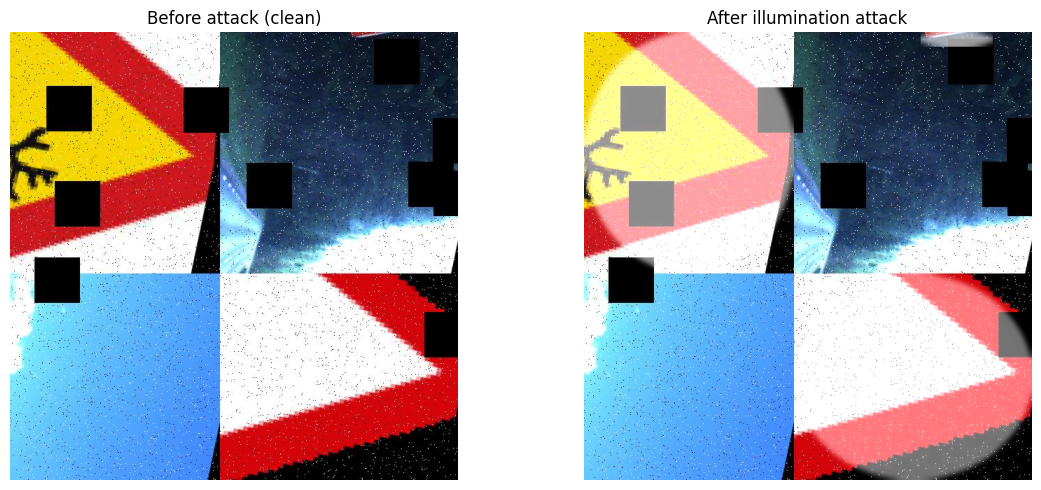

Sample image: ce85c1d8-a19-5_jpg.rf.698cf2f89fdcb3b392cff2665193897e.jpg (3 sign box(es))


In [7]:
import random
import matplotlib.pyplot as plt


def _preview_parse_label_file(label_path):
    class_ids, bboxes = [], []
    if not os.path.exists(label_path):
        return class_ids, bboxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_ids.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:5]])
    return class_ids, bboxes


attack_func = ATTACK_MAP[ATTACK_TYPE]
train_images_src = os.path.join(BASE_PATH, 'train/images')
train_labels_src = os.path.join(BASE_PATH, 'train/labels')

all_names = [f for f in os.listdir(train_images_src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random.seed(42)  # change for another deterministic sample
random.shuffle(all_names)
img_name = None
bboxes = []
for name in all_names:
    stem = name.rsplit('.', 1)[0]
    _, bboxes = _preview_parse_label_file(os.path.join(train_labels_src, stem + '.txt'))
    if bboxes:
        img_name = name
        break
if img_name is None:
    raise RuntimeError('No labeled training image found for preview.')

stem = img_name.rsplit('.', 1)[0]
src_img = os.path.join(train_images_src, img_name)
src_lbl = os.path.join(train_labels_src, stem + '.txt')
_, bboxes = _preview_parse_label_file(src_lbl)

img_clean = cv2.imread(src_img)
if img_clean is None:
    raise RuntimeError(f'Could not read {src_img}')

img_attacked = img_clean.copy()
for bbox in bboxes:
    img_attacked = attack_func(img_attacked, bbox)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img_clean, cv2.COLOR_BGR2RGB))
axes[0].set_title('Before attack (clean)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_attacked, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'After {ATTACK_TYPE} attack')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Sample image: {img_name} ({len(bboxes)} sign box(es))')


## Step 3 — Albumentations Augmentation Pipeline

In [8]:
# Applied to ALL training images (clean + attacked) to create a second augmented copy.
# This roughly doubles the effective dataset size with visually diverse variants.
# Labels are preserved and re-written for augmented copies.

augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.ImageCompression(quality_lower=75, quality_upper=100, p=0.3),
    A.RandomShadow(p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

print('Augmentation pipeline ready.')

Augmentation pipeline ready.


C:\Users\Karim\AppData\Local\Temp\ipykernel_35168\1817857958.py:11: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, quality_upper=100, p=0.3),


## Step 4 — Build the Expanded Training Set
For each training image this cell:
1. Optionally applies the attack (70% of images)
2. Saves the original (possibly attacked) image
3. Saves a second augmented copy with `_aug` suffix

Result: **~2x the original training set size**

In [9]:
def parse_label_file(label_path):
    class_ids, bboxes = [], []
    if not os.path.exists(label_path):
        return class_ids, bboxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_ids.append(int(parts[0]))
                bboxes.append([float(x) for x in parts[1:5]])
    return class_ids, bboxes


def build_expanded_train_set(base_path, train_folder, attack_type, split_ratio=0.7):
    train_images_src = os.path.join(base_path, 'train/images')
    train_labels_src = os.path.join(base_path, 'train/labels')

    robust_root   = os.path.join(base_path, train_folder)
    robust_images = os.path.join(robust_root, 'images')
    robust_labels = os.path.join(robust_root, 'labels')
    os.makedirs(robust_images, exist_ok=True)
    os.makedirs(robust_labels, exist_ok=True)

    attack_func = ATTACK_MAP[attack_type]

    all_images = [f for f in os.listdir(train_images_src) if f.endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(all_images)

    split_idx   = int(len(all_images) * split_ratio)
    attack_set  = set(all_images[:split_idx])

    print(f"Original images      : {len(all_images)}")
    print(f"  Attacked ({int(split_ratio*100)}%)    : {len(attack_set)}")
    print(f"  Clean    ({int((1-split_ratio)*100)}%)    : {len(all_images) - len(attack_set)}")
    print(f"  + Augmented copies  : {len(all_images)}")
    print(f"  Effective total     : ~{len(all_images) * 2}")
    print()

    skipped = 0
    for i, img_name in enumerate(all_images):
        if (i + 1) % 500 == 0:
            print(f"  Processing {i+1}/{len(all_images)}...")

        stem     = img_name.rsplit('.', 1)[0]
        lbl_name = stem + '.txt'
        src_img  = os.path.join(train_images_src, img_name)
        src_lbl  = os.path.join(train_labels_src, lbl_name)

        img = cv2.imread(src_img)
        if img is None or not os.path.exists(src_lbl):
            skipped += 1
            continue

        class_ids, bboxes = parse_label_file(src_lbl)

        # ── 1. Apply attack to the split_ratio fraction of images ──
        if img_name in attack_set:
            for bbox in bboxes:
                img = attack_func(img, bbox)

        # ── 2. Save original (possibly attacked) image + label ──
        cv2.imwrite(os.path.join(robust_images, img_name), img)
        shutil.copy(src_lbl, os.path.join(robust_labels, lbl_name))

        # ── 3. Save augmented copy ──
        try:
            if bboxes:
                result     = augment(image=img, bboxes=bboxes, class_labels=class_ids)
                aug_img    = result['image']
                aug_bboxes = result['bboxes']
                aug_labels = result['class_labels']
            else:
                aug_img, aug_bboxes, aug_labels = img, [], []
        except Exception:
            aug_img, aug_bboxes, aug_labels = img, bboxes, class_ids

        aug_img_name = stem + '_aug.jpg'
        aug_lbl_name = stem + '_aug.txt'
        cv2.imwrite(os.path.join(robust_images, aug_img_name), aug_img)
        with open(os.path.join(robust_labels, aug_lbl_name), 'w') as f:
            for cls, bbox in zip(aug_labels, aug_bboxes):
                f.write(f"{cls} {' '.join(f'{v:.6f}' for v in bbox)}\n")

    print(f"\nExpanded training set created at: {robust_root}")
    if skipped:
        print(f"Skipped {skipped} images (unreadable or missing labels).")


build_expanded_train_set(BASE_PATH, TRAIN_FOLDER, ATTACK_TYPE, SPLIT_RATIO)

Original images      : 1314
  Attacked (70%)    : 919
  Clean    (30%)    : 395
  + Augmented copies  : 1314
  Effective total     : ~2628

  Processing 500/1314...
  Processing 1000/1314...

Expanded training set created at: C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive\train_aug_illumination_70_30


## Step 5 — Generate YAMLs

In [10]:
import yaml

CLASS_NAMES = ['0', '1', '100', '101', '102', '103', '105', '106', '107', '108', '109', '110', '111', '112', '113', '115', '116', '117', '12', '120', '121', '122', '123', '124', '125', '127', '128', '129', '131', '132', '133', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '153', '154', '155', '156', '158', '159', '16', '161', '163', '164', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '177', '178', '179', '18', '180', '181', '19', '2', '20', '21', '22', '23', '24', '27', '28', '29', '3', '31', '32', '33', '34', '35', '36', '39', '4', '40', '41', '42', '43', '45', '46', '47', '48', '49', '5', '50', '50 meters between vehicles', '51', '52', '53', '54', '55', '56', '57', '59', '60', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '73', '74', '76', '78', '79', '8', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '93', '94', '95', '97', '98', '99', 'Advance direction sign exit ahead from other road than motorway or expressway', 'Axle weight limit-2ton', 'Bus stop', 'Cattle', 'Crossroad intersection', 'Crossroads', 'Cycle track', 'Cyclist and mopeds rides on carrigeway', 'Cyclists', 'Dangerous shoulder', 'Dip', 'Direction sign exit sign', 'Direction to be followed', 'End of all restrictions', 'End of lane reserved for public transport', 'Falling rocks', 'Filling station', 'First aid post', 'Give way (Yield)', 'Give way -Yield-', 'Guarded level crossing ahead', 'Height limit-3.5m', 'Horn prohibited', 'Hotel', 'Keep left', 'Left curve', 'Level crossing countdown marker', 'Loose gravel', 'Main highways', 'Marking for sharp bends', 'Motorway', 'Narrow bridge', 'Narrow road', 'National border', 'No Left turn', 'No Right turn', 'No entry', 'No entry for Trucks', 'No entry for bicycles', 'No entry for bullock carts', 'No entry for hand carts', 'No entry for motor vehicles', 'No entry for pedestrians', 'No parking', 'No passing', 'No snowmobiles', 'No stopping', 'No vehicles exceeding 12 tonnes', 'No vehicles exceeding length shown', 'No vehicles in both directions', 'No vehicles or combination of vehicles exceeding weight shown', 'Oblique side road junction', 'One-way traffic', 'Parking', 'Parking allowed for 15min', 'Passing without stopping prohibited', 'Pedestrian crossing', 'Priority over oncoming vehicles', 'Refreshments', 'Restaurant', 'Restriction zone', 'Right curve', 'Road hump', 'Road number sign', 'Roadworks', 'Roundabout', 'School', 'Side road junction', 'Slippery road', 'Speed refulcation bump', 'Staggered side road junction', 'Steep ascent', 'Steep descent', 'Steep downhill', 'Steep uphill', 'Stop', 'Stop at customs', 'Straight ahead', 'Symbol plate for specified vehicle or road user category', 'T-junction', 'Telephone', 'Traffic signals', 'Turn Right', 'Turn left', 'Turn left ahead', 'Turn left or straight ahead', 'Turn right ahead', 'Uneven road', 'Unguarded level crossing ahead', 'Unprotected quay', 'Weight limit-5ton', 'Y-junction', 'adjoining way', 'axle weight limit 30tonnes', 'end of the speed limit', 'exit', 'falling rocks (from) left', 'falling rocks -from- left', 'length limit-10m', 'lowspeed zone', 'no entry for bicycles and humans', 'no motorcycles', 'no turning left', 'no u turn', 'snowmobiles', 'speed limit-100', 'speed limit-110', 'speed limit-30', 'speed limit-50', 'speed limit-60', 'speed limit-70', 'speed limit-80', 'speed limit-90', 'speed-limit-120', 'tunnel in 2 km', 'two way traffic', 'warning wild animal']

# robust yaml — used during training (val = clean valid set)
with open(f'{BASE_PATH}/{ROBUST_YAML}', 'w') as f:
    yaml.dump({
        'path':  BASE_PATH,
        'train': f'{TRAIN_FOLDER}/images',
        'val':   'valid/images',
        'test':  'valid/images',
        'nc':    264,
        'names': CLASS_NAMES
    }, f)
print(f'{ROBUST_YAML} written')

# attack yaml — used for post-training evaluation (val = attacked val set)
with open(f'{BASE_PATH}/{ATTACK_YAML}', 'w') as f:
    yaml.dump({
        'path':  BASE_PATH,
        'train': f'{TRAIN_FOLDER}/images',
        'val':   'attacked_val/images',
        'test':  'attacked_val/images',
        'nc':    264,
        'names': CLASS_NAMES
    }, f)
print(f'{ATTACK_YAML} written')

robust_aug_illumination_70_30.yaml written
attack_aug_illumination_70_30.yaml written


## Step 6 — Train

In [11]:
from ultralytics import YOLO

BASE_MODEL_PT = os.path.join(ROOT_DIR, 'models', 'best.pt')
RUNS_DIR = os.path.join(ROOT_DIR, 'runs')
TRAINED_MODEL_PT = os.path.join(RUNS_DIR, RUN_NAME, 'weights', 'best.pt')

if not os.path.exists(BASE_MODEL_PT):
    raise FileNotFoundError(f"Base model not found at: {BASE_MODEL_PT}")

model = YOLO(BASE_MODEL_PT)

model.train(
    data=f'{BASE_PATH}/{ROBUST_YAML}',
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.001,
    # Albumentations already handles augmentation in preprocessing,
    # so YOLO's built-in mosaic/mixup are dialled down slightly
    mosaic=0.5,
    mixup=0.05,
    project=RUNS_DIR,
    name=RUN_NAME
)

New https://pypi.org/project/ultralytics/8.4.34 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.13.5 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive/robust_aug_illumination_70_30.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=trai

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([  1,   9,  20,  21,  26,  34,  64,  65,  72,  73,  87,  90, 102, 109, 111, 117, 118, 123, 140, 141, 152, 163, 164, 166, 168, 169, 176, 178, 183, 184, 200, 203, 212, 215, 217, 226, 230, 231, 233, 236, 237, 238, 257])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002274D42E350>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,

## Step 7 — Build Attacked Validation Set

In [12]:
def create_attacked_val_set(base_path, attack_type):
    val_images_src = os.path.join(base_path, 'valid/images')
    val_labels_src = os.path.join(base_path, 'valid/labels')
    attacked_root  = os.path.join(base_path, 'attacked_val')

    if os.path.exists(attacked_root):
        shutil.rmtree(attacked_root)
    os.makedirs(os.path.join(attacked_root, 'images'), exist_ok=True)
    os.makedirs(os.path.join(attacked_root, 'labels'), exist_ok=True)

    attack_func = ATTACK_MAP[attack_type]
    all_images  = [f for f in os.listdir(val_images_src) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Attacking {len(all_images)} validation images with '{attack_type}'...")

    for img_name in all_images:
        img      = cv2.imread(os.path.join(val_images_src, img_name))
        lbl_name = img_name.rsplit('.', 1)[0] + '.txt'
        src_lbl  = os.path.join(val_labels_src, lbl_name)
        dst_lbl  = os.path.join(attacked_root, 'labels', lbl_name)

        if os.path.exists(src_lbl):
            shutil.copy2(src_lbl, dst_lbl)
            _, bboxes = parse_label_file(src_lbl)
            for bbox in bboxes:
                img = attack_func(img, bbox)

        cv2.imwrite(os.path.join(attacked_root, 'images', img_name), img)

    print(f'Attacked validation set created at {attacked_root}')


create_attacked_val_set(BASE_PATH, ATTACK_TYPE)

Attacking 39 validation images with 'illumination'...
Attacked validation set created at C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive\attacked_val


## Step 8 — Evaluate

In [13]:
if not os.path.exists(TRAINED_MODEL_PT):
    raise FileNotFoundError(f"Trained model not found at: {TRAINED_MODEL_PT}")

robust_model = YOLO(TRAINED_MODEL_PT)

print('--- CLEAN VALIDATION DATA ---')
clean_results = robust_model.val(data=f'{BASE_PATH}/{ROBUST_YAML}')

print(f'\n--- {ATTACK_TYPE.upper()} ATTACKED VALIDATION DATA ---')
attack_results = robust_model.val(data=f'{BASE_PATH}/{ATTACK_YAML}')

print('\n' + '='*65)
print(f"{'Metric':<20} {'Clean Val':>18} {f'{ATTACK_TYPE} Attack':>18}")
print('-' * 65)
for label, key in zip(
    ['mAP50', 'mAP50-95', 'Precision', 'Recall'],
    ['metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']
):
    c = clean_results.results_dict.get(key, float('nan'))
    a = attack_results.results_dict.get(key, float('nan'))
    print(f"{label:<20} {c:>18.4f} {a:>18.4f}")
print('=' * 65)

--- CLEAN VALIDATION DATA ---
Ultralytics 8.4.33  Python-3.13.5 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
Model summary (fused): 73 layers, 3,390,416 parameters, 0 gradients, 9.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 354.4124.2 MB/s, size: 41.4 KB)
val: Scanning C:\Users\Karim\Desktop\Road-Sign-Detection-Model\datasets\archive\valid\labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 16.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.1s0.5ss
                   all         39         74      0.601      0.432      0.623      0.532
                     1          1          1      0.202          1      0.995      0.697
                   108          1          1          1          0      0.995      0.697
                   121          1          2          1          0      0.256      0.256
                   122          1          1       

## Step 9 — Download Model

In [14]:
if os.path.exists('/content'):
    from google.colab import files
    files.download(TRAINED_MODEL_PT)
else:
    print(f'Trained model path: {TRAINED_MODEL_PT}')

Trained model path: C:\Users\Karim\Desktop\Road-Sign-Detection-Model\runs\yolov8_illumination_70_30\weights\best.pt
